# Практическая работа 6
#### Цель работы: Провести AB-тестирование. По результату расчета значения p-value и построения распределения конверсии, используя бутстрап-метод, сделать вывод – являются ли результаты тестируемой группы (группа B – новый магазин) статистически лучше, или же это произошло случайно? Имеет ли смысл полностью обновлять дизайн или лучше оставить старый?

Импортируем библиотеки для AB-тестирования.

In [930]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

Расспределим датасеты (21.03.2025) по переменным.

In [931]:
visits_a = pd.read_csv('old_shop_visits.csv')
visits_b = pd.read_csv('new_shop_visits.csv')
orders_a = pd.read_csv('old_shop_orders.csv')
orders_b = pd.read_csv('new_shop_orders.csv')

Удалим дубликаты из датафреймов если они там есть.

In [932]:
visits_a.dropna(inplace=True)
visits_b.dropna(inplace=True)
orders_a.dropna(inplace=True)
orders_b.dropna(inplace=True)

Добавим к датафреймам с orders столбец с буквой.

In [933]:
orders_a['group'] = 'A'
orders_b['group'] = 'B'

Теперь сольем старые датафрейм с новым.

In [934]:
visits = pd.concat([visits_a, visits_b], ignore_index=True)
orders = pd.concat([orders_a, orders_b], ignore_index=True)

1. Вычислим `конверсию в покупку по типу устройств`.

Формула для нахождения конверсии:

`Конверсия = Уникальные пользователи / Всего посетителей`

Для этого нужно сначала получить список уникальных `user_id` с визитов по устройству. После того, как сформировали данный список, получаем именно количество уникальных заказов (уникальных покупателей), и уже считаем конверсию и используем данные для расчета `p-value`.

Для начала сделаем конверсию для пользователей с мобильных устройств.

In [935]:
# Уникальные пользователи по группам и устройствам (только Mobile)
unique_users_mobile = visits[visits['device'] == 'Mobile'].groupby('group')['user_id'].nunique()
users_from_mobile = list(visits[visits['device'] == 'Mobile']['user_id'].unique())

# Уникальные покупатели по группам и устройствам (только Mobile)
unique_buyers_mobile = orders[orders['user_id'].isin(users_from_mobile)].groupby('group')['user_id'].nunique()

# Расчет конверсии в покупку по группам и устройствам (только Mobile)
conversion_users_mobile = (unique_buyers_mobile / unique_users_mobile) * 100

print('Конверсия в покупку по типу устройств (Mobile) (%):')
print(conversion_users_mobile)

Конверсия в покупку по типу устройств (Mobile) (%):
group
A     7.692308
B    23.529412
Name: user_id, dtype: float64


Теперь создадим конверсию для пользователей с Desktop.

In [936]:
# Уникальные пользователи по группам и устройствам (только Desktop)
unique_users_desktop = visits[visits['device'] == 'Desktop'].groupby('group')['user_id'].nunique()
users_from_desktop = list(visits[visits['device'] == 'Desktop']['user_id'].unique())

# Уникальные покупатели по группам и устройствам (только Desktop)
unique_buyers_desktop = orders[orders['user_id'].isin(users_from_desktop)].groupby('group')['user_id'].nunique()

# Расчет конверсии в покупку по группам и устройствам (только Desktop)
conversion_users_desktop = (unique_buyers_desktop / unique_users_desktop) * 100

print('Конверсия в покупку по типу устройств (Desktop) (%):')
print(conversion_users_desktop)

Конверсия в покупку по типу устройств (Desktop) (%):
group
A    35.294118
B    51.923077
Name: user_id, dtype: float64


Нулевая гипотеза (`H0`): Конверсия в покупку на мобильных устройствах для группы B увеличится.

Альтернативная гипотеза (`H1`): Конверсия в покупку на мобильных устройствах для группы B уменьшится.

Для того чтобы подвердить или опровергнуть нулевую гипотезу найдем `p-value`.

`p-value` — это вероятность получить наши данные в реальности, где нулевая гипотеза верна.

`Важно`: p-value не позволяет нам сказать, с какой вероятностью верна нулевая гипотеза. Этот показатель оценивает вероятность результата статистического теста в альтернативной реальности, а не нулевую гипотезу в нашей.

In [937]:
successes = [unique_buyers_mobile['B'], unique_buyers_mobile['A']]
trials = [unique_users_mobile['B'], unique_users_mobile['A']]
z_stat, p_value_users = proportions_ztest(successes, trials)

print('\nP-value для конверсия в покупку по типу устройств (Mobile):',f'{p_value_users:.3f}')


P-value для конверсия в покупку по типу устройств (Mobile): 0.249


На основании полученного `p-value`, равного `0.249`, можно сделать следующий вывод:

`p-value` (`0.249`) > α (уровень значимости, обычно `0.05`): Это означает, что у нас недостаточно статистических доказательств, чтобы отвергнуть нулевую гипотезу.

Существует вероятность в `24.9%` получить наблюдаемую разницу в конверсии между группами `A` и `B`, если на самом деле нулевая гипотеза `верна`. 

Мы `не можем отвергнуть` нулевую гипотезу. Другими словами, у нас недостаточно данных, чтобы подтвердить, что изменения, наблюдаемые в конверсии, статистически значимы и не являются случайными колебаниями.

Теперь найдем `p-value` для пользователей на Desktop.

Нулевая гипотеза (`H0`): Конверсия в покупку на десктопных устройствах для группы B увеличится.

Альтернативная гипотеза (`H1`): Конверсия в покупку на десктопных устройствах для группы B уменьшится.

Для того чтобы подвердить или опровергнуть нулевую гипотезу найдем `p-value`.


In [938]:
successes = [unique_buyers_desktop['B'], unique_buyers_desktop['A']]
trials = [unique_users_desktop['B'], unique_users_desktop['A']]
z_stat, p_value_users = proportions_ztest(successes, trials)

print('\nP-value для конверсия в покупку по типу устройств (Desktop):', f'{p_value_users:.3f}')


P-value для конверсия в покупку по типу устройств (Desktop): 0.130


На основании полученного `p-value`, равного `0.13`, можно сделать следующий вывод:

`p-value` (`0.13`) > α: Это означает, что у нас недостаточно статистических доказательств, чтобы отвергнуть нулевую гипотезу.

Существует вероятность в `13%` получить наблюдаемую разницу в конверсии между группами `A` и `B`, если на самом деле нулевая гипотеза `верна`. 

Мы `не можем отвергнуть` нулевую гипотезу. Другими словами, у нас недостаточно данных, чтобы подтвердить, что изменения, наблюдаемые в конверсии, статистически значимы и не являются случайными колебаниями.

In [939]:
fig = make_subplots(rows=1, cols=2, subplot_titles=(
    'Конверсия в покупку для Mobile', 'Конверсия в покупку для Desktop'))

# Mobile
fig.add_trace(go.Bar(x=conversion_users_mobile.index, 
                     y=conversion_users_mobile.values, 
                     marker_color=['blue', 'orange'], name='Mobile'), row=1, col=1)
# Desktop
fig.add_trace(go.Bar(x=conversion_users_desktop.index, 
                     y=conversion_users_desktop.values, 
                     marker_color=['blue', 'orange'], name='Desktop'), row=1, col=2)

fig.update_layout(height=500, width=1200, title_text="Конверсия в покупку", showlegend=False)
fig.update_yaxes(title_text="Конверсия, %", row=1, col=1)
fig.show()

По итогу построения графиков можно видеть, что группа `B` действительно имеет прирост. Больший прирост заметен на `мобильных` устройствах. Следовательно изменения в `B` группе сильно повлияли на `user-frendly` для мобильных пользователей и теперь покупки на данном типе устройств стало совершать проще и удобней.

Теперь создадим бутстрап метод для конверсии в покупку.

`Бутстрап` (Bootstrap) метод в Data Analytics — это мощная статистическая техника, которая позволяет оценивать распределение выборочной статистики (например, среднего, медианы, стандартного отклонения) или модели на основе имеющихся данных, не делая сильных предположений о распределении генеральной совокупности.

`Оценка неопределенности`: Бутстрап помогает оценить, насколько надежна выборочная статистика и насколько она может варьироваться, если бы мы взяли другие выборки из той же генеральной совокупности.

`Проверка гипотез`: Бутстрап можно использовать для проверки статистических гипотез, особенно в ситуациях, когда не выполняются условия применимости традиционных тестов.

In [940]:
def bootstrap_conversion(visits, orders, n_samples=1000):
    conversions = []
    for _ in range(n_samples):
        sample_visits = np.random.choice(
            [0, 1], size=visits, p=[1 - orders / visits, orders / visits])
        conversions.append(np.mean(sample_visits))
    return conversions

Фильтруем данные для мобильных устройств, после чего группируем данные по группам.

In [941]:
# Фильтруем данные для мобильных устройств
visits_mobile = visits[visits['device'] == 'Mobile']
orders_mobile = orders[orders['user_id'].isin(visits_mobile['user_id'].unique())]

# Группируем данные по группам
visits_per_group_mobile = visits_mobile.groupby('group')['session_id'].count()
orders_per_group_mobile = orders_mobile.groupby('group')['id'].count()

Тоже самое делаем и для пользователей на десктопах.

In [942]:
# Фильтруем данные для десктоп устройств
visits_desktop = visits[visits['device'] == 'Desktop']
orders_desktop = orders[orders['user_id'].isin(visits_desktop['user_id'].unique())]

# Группируем данные по группам
visits_per_group_desktop = visits_desktop.groupby('group')['session_id'].count()
orders_per_group_desktop = orders_desktop.groupby('group')['id'].count()

Теперь используем бутстрап метод для пользователей на мобильных устройств.

In [943]:
boot_a_mobile = bootstrap_conversion(
    visits_per_group_mobile['A'], orders_per_group_mobile['A'])
boot_b_mobile = bootstrap_conversion(
    visits_per_group_mobile['B'], orders_per_group_mobile['B'])

Также используем метод бустрапа и для пользователей на десктопе.

In [944]:
boot_a_desktop = bootstrap_conversion(
    visits_per_group_desktop['A'], orders_per_group_desktop['A'])
boot_b_desktop = bootstrap_conversion(
    visits_per_group_desktop['B'], orders_per_group_desktop['B'])

Построим два графика расспределения конверсии в покупку для мобильных и десктопных устройств.

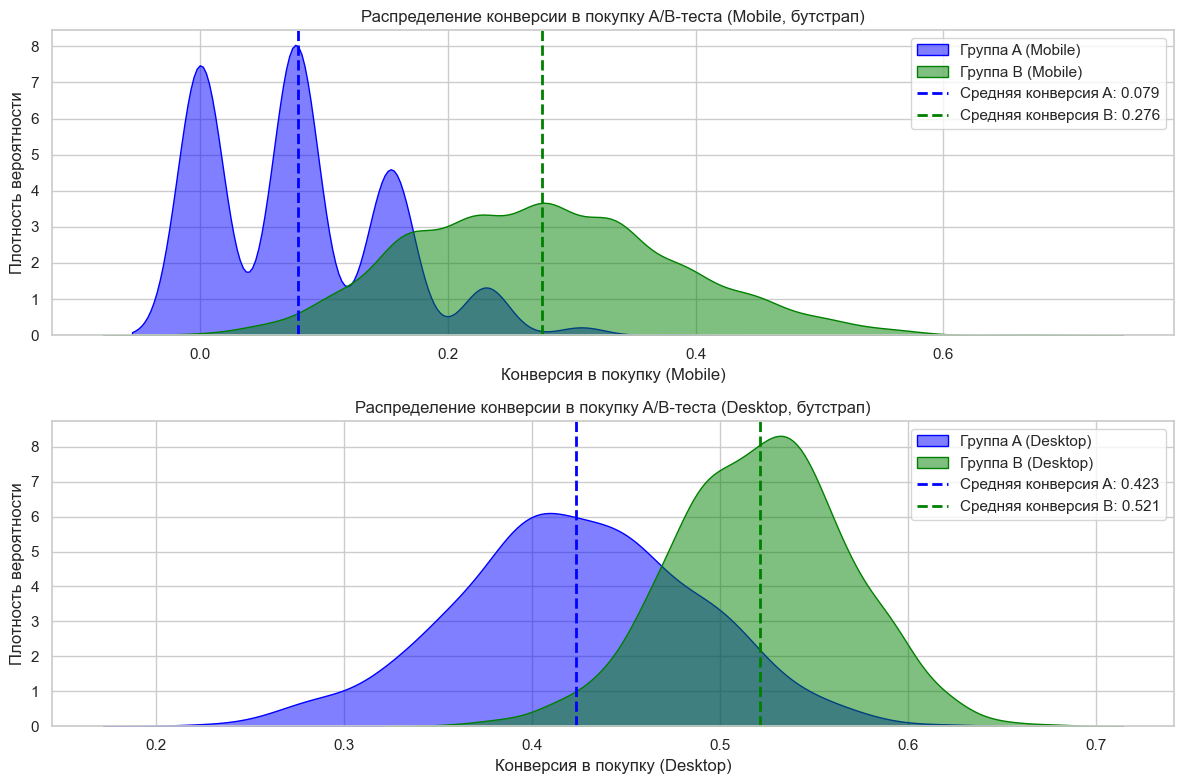

In [945]:
plt.figure(figsize=(12, 8))

# Mobile данные
plt.subplot(2, 1, 1)  # 2 строки, 1 столбец, первая ячейка
sns.kdeplot(boot_a_mobile, label='Группа A (Mobile)', fill=True, color='blue', alpha=0.5)
sns.kdeplot(boot_b_mobile, label='Группа B (Mobile)', fill=True, color='green', alpha=0.5)
plt.axvline(np.mean(boot_a_mobile), color='blue', linestyle='dashed',
            linewidth=2, label=f'Средняя конверсия A: {np.mean(boot_a_mobile):.3f}')
plt.axvline(np.mean(boot_b_mobile), color='green', linestyle='dashed',
            linewidth=2, label=f'Средняя конверсия B: {np.mean(boot_b_mobile):.3f}')
plt.xlabel('Конверсия в покупку (Mobile)')
plt.ylabel('Плотность вероятности')
plt.title('Распределение конверсии в покупку A/B-теста (Mobile, бутстрап)')
plt.legend()
plt.grid(True)


# Desktop данные
plt.subplot(2, 1, 2) 
sns.kdeplot(boot_a_desktop, label='Группа A (Desktop)', fill=True, color='blue', alpha=0.5)
sns.kdeplot(boot_b_desktop, label='Группа B (Desktop)', fill=True, color='green', alpha=0.5)
plt.axvline(np.mean(boot_a_desktop), color='blue', linestyle='dashed',
            linewidth=2, label=f'Средняя конверсия A: {np.mean(boot_a_desktop):.3f}')
plt.axvline(np.mean(boot_b_desktop), color='green', linestyle='dashed',
            linewidth=2, label=f'Средняя конверсия B: {np.mean(boot_b_desktop):.3f}')
plt.xlabel('Конверсия в покупку (Desktop)')
plt.ylabel('Плотность вероятности')
plt.title('Распределение конверсии в покупку A/B-теста (Desktop, бутстрап)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

На основе графиков распределения конверсий можно сделать следующие выводы:

Mobile:

Группа `B` (Mobile) `значительно превосходит` группу `A` (Mobile). Распределение конверсии для группы `B` смещено вправо и имеет более высокую среднюю конверсию (`0.277`) по сравнению с группой `A` (`0.076`). Расспределения перекрываются не сильно. Это говорит о том, что изменения, внесенные в группу `B`, привели к `значительному увеличению` конверсии на мобильных устройствах.

Распределение для группы `A` (Mobile) имеет два пика. Это может указывать на наличие двух разных сегментов пользователей или факторов, влияющих на конверсию.

Desktop:

Группа `B` (Desktop) также превосходит группу `A` (Desktop), но не так значительно, как на мобильных устройствах. Средняя конверсия для группы `B` (`0.524`) выше, чем для группы `A` (`0.424`). Распределения частично перекрываются.

По сравнению с мобильными устройствами, конверсия на десктопах в целом выше для обеих групп. Это ожидаемо, так как пользователям часто удобнее совершать покупки с десктопа.

Влияние изменений, внесенных в группу `B`, более заметно на мобильных устройствах, чем на десктопах.

Общие выводы:

A/B-тест показал, что изменения, внесенные в группу `B`, `положительно повлияли` на конверсию как на мобильных устройствах, так и на десктопах. Влияние изменений более выражено на `мобильных` устройствах.

2. Вычислим `средний чек`.

Формула для нахождения среднего чека:
`AOV = Общая выручка / Кол-во заказов`

In [946]:
# Общая выручка
total_revenue = orders.groupby('group')['total_cost'].sum()

# Количество заказов
total_orders = orders.groupby('group')['id'].count()

# Средний чек (AOV)
average_order_value = total_revenue / total_orders

print('Средний чек (AOV):')
print(average_order_value)

Средний чек (AOV):
group
A    162.423077
B    142.596774
dtype: float64


Нулевая гипотеза (`H0`): Средний чек для группы B увеличится.

Альтернативная гипотеза (`H1`): Средний чек для группы B уменьшится.

Для того чтобы подвердить или опровергнуть нулевую гипотезу найдем `p-value`.

Вместо `Z-теста`, который мы использовали для конверсии будем использовать `t-тест` для количественных метрик.

In [947]:
# Получаем выборки для каждой группы для t-test
group_a = orders[orders['group'] == 'A']['total_cost']
group_b = orders[orders['group'] == 'B']['total_cost']

# Проводим t-test (предполагаем независимые выборки)
t_stat, p_value_aov = ttest_ind(group_a, group_b)

print('\nP-value для сравнения среднего чека (AOV):', f'{p_value_aov:.3f}')


P-value для сравнения среднего чека (AOV): 0.470


На основании полученного `p-value`, равного `0.47`, можно сделать следующий вывод:

`p-value` (`0.47`) > α: Это означает, что у нас недостаточно статистических доказательств, чтобы отвергнуть нулевую гипотезу.

Существует вероятность в `47%` получить наблюдаемую разницу в конверсии между группами `A` и `B`, если на самом деле нулевая гипотеза `верна`. 

Мы `не можем отвергнуть` нулевую гипотезу. Другими словами, у нас недостаточно данных, чтобы подтвердить, что изменения, статистически значимы и не являются случайными колебаниями.

In [948]:
fig = go.Figure()

fig.add_trace(go.Bar(x=average_order_value.index,
                     y=average_order_value.values,
                     marker_color=['blue', 'orange']))

fig.update_layout(height=500, width=1200,
                  title_text="Средний чек", showlegend=False)
fig.update_yaxes(title_text="Средний чек, руб")

fig.show()

По итогу построения графика можно увидеть, что контрольная группа `А` имеет средний чек больше чем группа `B`. Прироста в среднем чеке у группы `B` как было предложено в `нулевой гипотезе` не наблюдается.

Теперь создадим бутстрап метод для вычисления среднего.

In [949]:
def bootstrap_means(data, n_samples=1000):
    means = []
    for _ in range(n_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return means

Получаем выборки для каждой группы.

In [950]:
group_a = orders[orders['group'] == 'A']['total_cost']
group_b = orders[orders['group'] == 'B']['total_cost']

После чего выполняем бутстрап метод для обеих групп.

In [951]:
boot_a = bootstrap_means(group_a)
boot_b = bootstrap_means(group_b)

Теперь построим график расспредления средних значений для группы `A` и `B`.

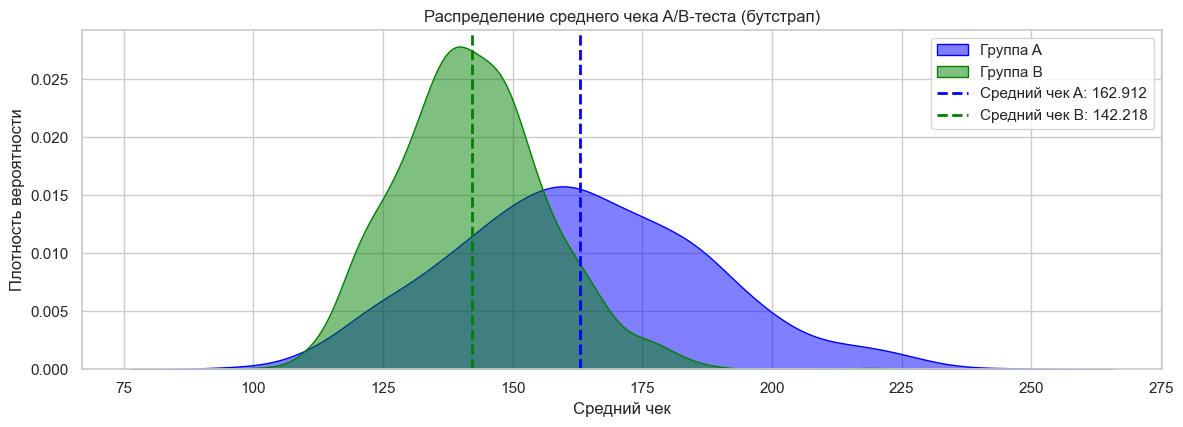

In [952]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
sns.kdeplot(boot_a, label='Группа A', fill=True, color='blue', alpha=0.5)
sns.kdeplot(boot_b, label='Группа B', fill=True, color='green', alpha=0.5)
plt.axvline(np.mean(boot_a), color='blue', linestyle='dashed',
            linewidth=2, label=f'Средний чек A: {np.mean(boot_a):.3f}')
plt.axvline(np.mean(boot_b), color='green', linestyle='dashed',
            linewidth=2, label=f'Средний чек B: {np.mean(boot_b):.3f}')
plt.xlabel('Средний чек')
plt.ylabel('Плотность вероятности')
plt.title('Распределение среднего чека A/B-теста (бутстрап)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

На основе графика можно сделать вывод о наблюдаемой разницы в средних чеках:

Разница составляет `18.191` в пользу группы `A`.

Бутстрап-анализ показывает, что распределения средних чеков групп `A` и `B` практически не перекрываются (на основе графика плотности вероятности). Это указывает на то, что разница между группами статистически значима (`p-value < 0.05`). Что в корне `противоположно` p-value высчитанной ранеее.

Группа `A` демонстрирует существенно более высокий средний чек. Это может быть связано с тем, что пользователи привыкли к старому интерфейсу и покупают там охотней.

3. Вычислим `среднее количество товаров в заказе`.

Формула для нахождения среднего кол-во товаров в заказе:

`Ср. кол-во товаров в заказе = сумма всех товаров в заказе / Кол-во заказов`

В столбце `quantities` данные хранятся списком из-за чего мы не сможем посчитать сумму товаров. Поэтому сначала через лямбду выражения список превратим в число.

In [953]:
# Преобразуем список в числа
orders['quantities'] = orders['quantities'].apply(
    lambda x: sum(map(int, str(x).split(', '))) if isinstance(x, str) else x
)

# Сумма всех товаров в заказе
total_quantities = orders.groupby('group')['quantities'].sum()

# Количество заказов
total_orders = orders.groupby('group')['id'].count()

# Ср. кол-во товаров в заказе
average_order_quantities = total_quantities / total_orders

print('Ср. кол-во товаров в заказе:')
print(average_order_quantities)

Ср. кол-во товаров в заказе:
group
A    2.000000
B    1.693548
dtype: float64


Нулевая гипотеза (`H0`): Ср. кол-во товаров в заказе увеличится.

Альтернативная гипотеза (`H1`): Ср. кол-во товаров в заказе уменьшиться.

Для того чтобы подвердить или опровергнуть нулевую гипотезу найдем `p-value`.

In [954]:
# Получаем выборки для каждой группы для t-test
group_a = orders[orders['group'] == 'A']['quantities']
group_b = orders[orders['group'] == 'B']['quantities']

# Проводим t-test (предполагаем независимые выборки)
t_stat, p_value_aov = ttest_ind(group_a, group_b)

print('\nP-value для ср. кол-во товаров в заказе:', f'{p_value_aov:.3f}')


P-value для ср. кол-во товаров в заказе: 0.284


На основании полученного `p-value`, равного `0.284`, можно сделать следующий вывод:

`p-value` (`0.284`) > α: Это означает, что у нас недостаточно статистических доказательств, чтобы отвергнуть нулевую гипотезу.

Существует вероятность в `28.4%` получить наблюдаемую разницу в конверсии между группами `A` и `B`, если на самом деле нулевая гипотеза `верна`. 

Мы `не можем отвергнуть` нулевую гипотезу. Другими словами, у нас недостаточно данных, чтобы подтвердить, что изменения, наблюдаемые в конверсии, статистически значимы и не являются случайными колебаниями.

In [955]:
fig = go.Figure()

fig.add_trace(go.Bar(x=average_order_quantities.index,
                     y=average_order_quantities.values,
                     marker_color=['pink', 'purple']))

fig.update_layout(height=500, width=1200,
                  title_text="Ср. кол-во товаров в заказе", showlegend=False)
fig.update_yaxes(title_text="Товаров, кол-во")

fig.show()

После построения графика можно увидеть, что как и в предыдущий раз лидирует группа выборки `A`. Возможно все по той же причине.

In [956]:
def bootstrap_means(data, n_samples=1000):
    means = []
    for _ in range(n_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return means

Получаем выборки для групп.

In [957]:
group_a_quantities = orders[orders['group'] == 'A']['quantities']
group_b_quantities = orders[orders['group'] == 'B']['quantities']

Используем бутстрап метод для расспределения.

In [958]:
boot_a_quantities = bootstrap_means(group_a_quantities)
boot_b_quantities = bootstrap_means(group_b_quantities)

Теперь построим график расспредления среднего количества товаров для группы `A` и `B`.

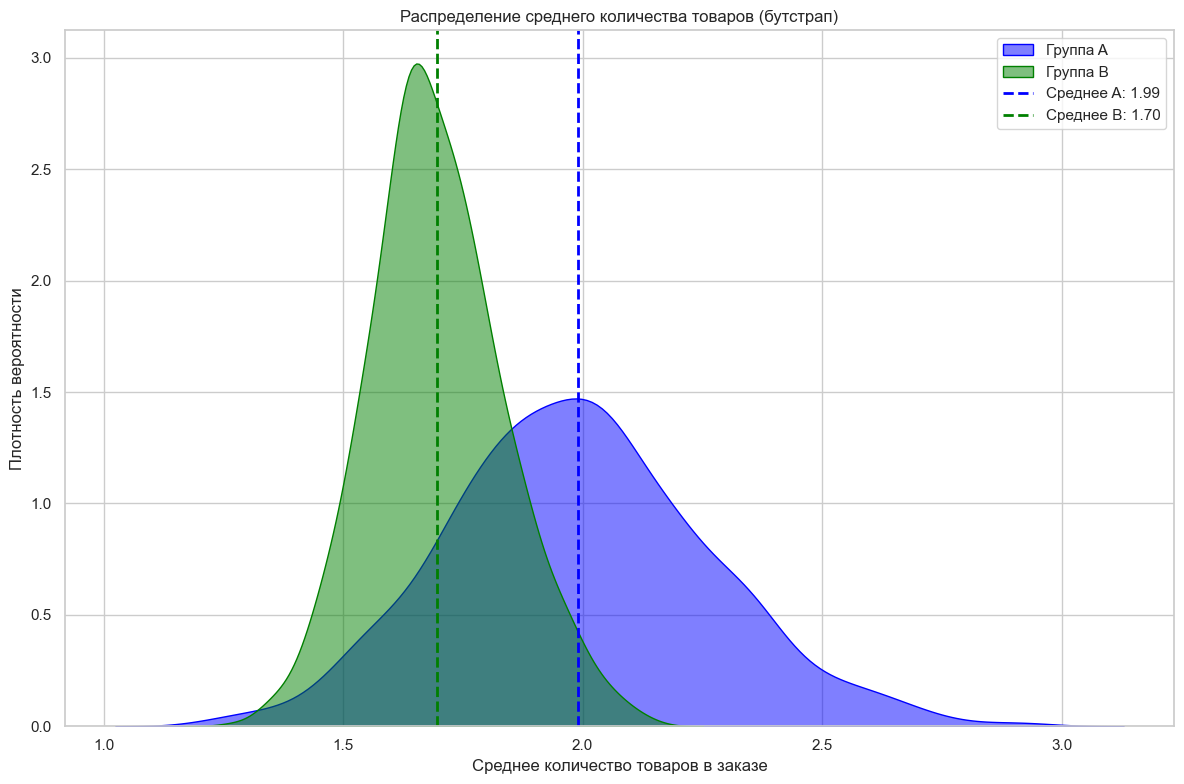

In [959]:
# Построение графика
plt.figure(figsize=(12, 8))

# График распределения средних значений
sns.kdeplot(boot_a_quantities, label='Группа A',
            fill=True, color='blue', alpha=0.5)
sns.kdeplot(boot_b_quantities, label='Группа B',
            fill=True, color='green', alpha=0.5)
plt.axvline(np.mean(boot_a_quantities), color='blue', linestyle='dashed',
            linewidth=2, label=f'Среднее A: {np.mean(boot_a_quantities):.2f}')
plt.axvline(np.mean(boot_b_quantities), color='green', linestyle='dashed',
            linewidth=2, label=f'Среднее B: {np.mean(boot_b_quantities):.2f}')
plt.xlabel('Среднее количество товаров в заказе')
plt.ylabel('Плотность вероятности')
plt.title('Распределение среднего количества товаров (бутстрап)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Сделаем вывод по результатам A/B-теста для среднего количества товаров в заказе:

Разница составляет `0.32` в пользу группы `A`.

Распределения средних значений, полученные методом бутстрапа, практически `не перекрываются` (на основе графика плотности вероятности). Это указывает на статистическую значимость различий между группами (`p-value < 0.05`). Что противоречит `p-value` высчитанной ранее.

4. Вычислим `среднее время на сайте перед покупкой`.

Формула для нахождения среднего времени на сайте перед покупкой:

`Ср. время на сайте = общее время в сессиях с покупкой / кол-во сессий с покупками`

In [960]:
# Общее время в сессиях перед покупкой
total_time_spent_with_order  = visits[visits['total_amount'] >= 1].groupby('group')['time_spent'].sum()

# Количество сессий с покупками
total_session_with_order = visits[visits['total_amount'] >= 1].groupby('group')['total_amount'].count()

# Ср. время на сайте
average_time_spent = total_time_spent_with_order / total_session_with_order

print('Среднее время на сайте перед покупкой:')
print(average_time_spent)

Среднее время на сайте перед покупкой:
group
A    746.058824
B    206.676471
dtype: float64


Нулевая гипотеза (`H0`): Ср. время на сайте перед покупкой уменьшиться.

Альтернативная гипотеза (`H1`): Ср. время на сайте перед покупкой увеличится.

Для того чтобы подвердить или опровергнуть нулевую гипотезу найдем `p-value`.

In [961]:
visits_with_purchase = visits[visits['total_amount'] >= 1]

# Получаем выборки для каждой группы (A и B)
group_a = visits_with_purchase[visits_with_purchase['group'] == 'A']['time_spent']
group_b = visits_with_purchase[visits_with_purchase['group'] == 'B']['time_spent']

# Проводим t-test (предполагаем независимые выборки)
t_stat, p_value = ttest_ind(group_a, group_b)

print('\nP-value для ср. времени на сайте перед покупкой:', f'{p_value:.3f}')


P-value для ср. времени на сайте перед покупкой: 0.005


На основании полученного `p-value`, равного `0.005`, можно сделать следующий вывод:

`p-value` (`0.005`) < α: Это означает, что у нас достаточно статистических доказательств, чтобы отвергнуть нулевую гипотезу.

Существует вероятность в `0.5%` получить наблюдаемую разницу в конверсии между группами `A` и `B`, если на самом деле нулевая гипотеза `верна`. 

Мы `можем отвергнуть` нулевую гипотезу. Другими словами, у нас достаточно данных, чтобы подтвердить, что изменения, наблюдаемые в конверсии, статистически не значимы и являются случайными колебаниями.

In [962]:
fig = go.Figure()

fig.add_trace(go.Bar(x=average_time_spent.index,
                     y=average_time_spent.values,
                     marker_color=['pink', 'purple']))

fig.update_layout(height=500, width=1200,
                  title_text="Ср. время на сайте перед покупкой", showlegend=False)
fig.update_yaxes(title_text="Время, секунды")

fig.show()

По результатам графика можно видеть, что группа `B` совершает покупки быстрее, как было и утверждено в нулевой гипотезе, хоть и p-value был мал.

Воспользуемся бутстрап методом.

In [963]:
def bootstrap_means(data, n_samples=1000):
    means = []
    for _ in range(n_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return means

Сгруппируем данные.

In [964]:
visits_with_purchase = visits[visits['total_amount'] >= 1]

# Получаем выборки для каждой группы (A и B)
group_a = visits_with_purchase[visits_with_purchase['group'] == 'A']['time_spent']
group_b = visits_with_purchase[visits_with_purchase['group'] == 'B']['time_spent']

Воспользуемся бутстрап методом.

In [965]:
boot_a_time = bootstrap_means(group_a)
boot_b_time = bootstrap_means(group_b)

Строим график расспределения среднего времени на сайте перед покупкой.

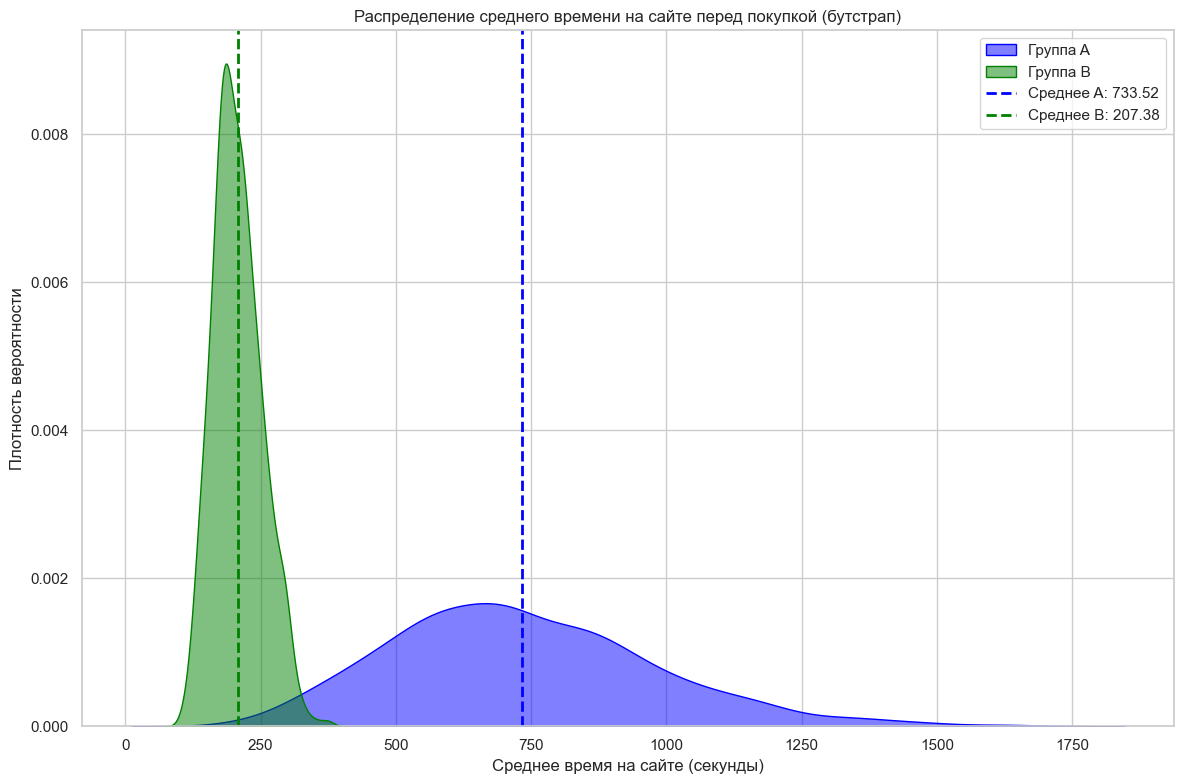

In [966]:
plt.figure(figsize=(12, 8))

sns.kdeplot(boot_a_time, label='Группа A',
            fill=True, color='blue', alpha=0.5)
sns.kdeplot(boot_b_time, label='Группа B',
            fill=True, color='green', alpha=0.5)
plt.axvline(np.mean(boot_a_time), color='blue', linestyle='dashed',
            linewidth=2, label=f'Среднее A: {np.mean(boot_a_time):.2f}')
plt.axvline(np.mean(boot_b_time), color='green', linestyle='dashed',
            linewidth=2, label=f'Среднее B: {np.mean(boot_b_time):.2f}')
plt.xlabel('Среднее время на сайте (секунды)')
plt.ylabel('Плотность вероятности')
plt.title('Распределение среднего времени на сайте перед покупкой (бутстрап)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Вывод по результатам A/B-теста (бутстрап):

Разница составляет `544.21` секунды (в `3.6` раза выше в группе `A`). Как и ожидалось в `нулевой гипотезе`.

Распределения средних значений, полученные методом бутстрапа, практически не перекрываются. Это указывает на статистическую значимость различий (`p-value < 0.05`).

Уменьшенее времени на сайте в группе `B` может быть связано с более интуитивно понятным интерфейсом для совершения покупки.

5. Вычислим `среднее количество просмотренных страниц перед покупкой`.

Формула для нахождения среднего кол-ва просмотренных страниц перед покупкой:

`Ср. время на сайте = общее время в сессиях с покупкой / кол-во сессий с покупками`

In [967]:
# Общее количество просмотренных страниц перед покупкой
total_page_views_with_order  = visits[visits['total_amount'] >= 1].groupby('group')['page_views'].sum()

# Количество сессий с покупками
total_session_with_order = visits[visits['total_amount'] >= 1].groupby('group')['total_amount'].count()

# Ср. кол-во просмотренных страниц 
average_page_views = total_page_views_with_order / total_session_with_order

print('Среднее количество просмотренных страниц перед покупкой:')
print(average_page_views)

Среднее количество просмотренных страниц перед покупкой:
group
A    23.294118
B    15.617647
dtype: float64


Проведем двойное тестирование, где нам важно изменение в любую сторону. Для этого нужно будет после умнодит `p-value` на два.

Нулевая гипотеза (`H0`): Ср. количество просмотренных страниц перед покупкой изменится.

Альтернативная гипотеза (`H1`): Ср. количество просмотренных страниц перед покупкой изменится.

Для того чтобы подвердить или опровергнуть нулевую гипотезу найдем `p-value`.

In [968]:
visits_with_purchase = visits[visits['total_amount'] >= 1]

# Получаем выборки для каждой группы (A и B)
group_a = visits_with_purchase[visits_with_purchase['group'] == 'A']['page_views']
group_b = visits_with_purchase[visits_with_purchase['group'] == 'B']['page_views']

# Проводим t-test (предполагаем независимые выборки)
t_stat, p_value = ttest_ind(group_a, group_b)

print('\nP-value для ср. кол-во просмотренных страниц перед покупкой:', f'{p_value*2:.3f}')


P-value для ср. кол-во просмотренных страниц перед покупкой: 0.177


На основании полученного `p-value`, равного `0.177`, можно сделать следующий вывод:

`p-value` (`0.177`) > α: Это означает, что у нас недостаточно статистических доказательств, чтобы отвергнуть нулевую гипотезу.

Существует вероятность в `17.7%` получить наблюдаемую разницу в конверсии между группами `A` и `B`, если на самом деле нулевая гипотеза `верна`. 

Мы `не можем отвергнуть` нулевую гипотезу. Другими словами, у нас недостаточно данных, чтобы подтвердить, что изменения, наблюдаемые в конверсии, статистически значимы и не являются случайными колебаниями.

In [969]:
fig = go.Figure()

fig.add_trace(go.Bar(x=average_page_views.index,
                     y=average_page_views.values,
                     marker_color=['red', 'green']))

fig.update_layout(height=500, width=1200,
                  title_text="Ср. кол-во просмотренных страниц перед покупкой", showlegend=False)
fig.update_yaxes(title_text="Страницы, кол-во")

fig.show()

Как и ожидалось в нулевой гипотезе группа `B` изменилась. Среднее кол-во просмотренных страниц перед покупкой у группы `B` меньше, следовательно новый интерфейс позволяет пользователям меньше времени тратить на поиск перед покупкой, что помогает людям совершать импульсивные покупки.

Теперь используем бутстрап метод для среднего.

In [970]:
def bootstrap_means(data, n_samples=1000):
    means = []
    for _ in range(n_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return means

Получаем выборки для каждой группы.

In [971]:
visits_with_purchase = visits[visits['total_amount'] >= 1]

group_a = visits_with_purchase[visits_with_purchase['group'] == 'A']['page_views']
group_b = visits_with_purchase[visits_with_purchase['group'] == 'B']['page_views']

Используем бутстрап-метод.

In [972]:
boot_a_time = bootstrap_means(group_a)
boot_b_time = bootstrap_means(group_b)

Строим график распределения среднего кол-во просмотренных страниц перед покупкой.

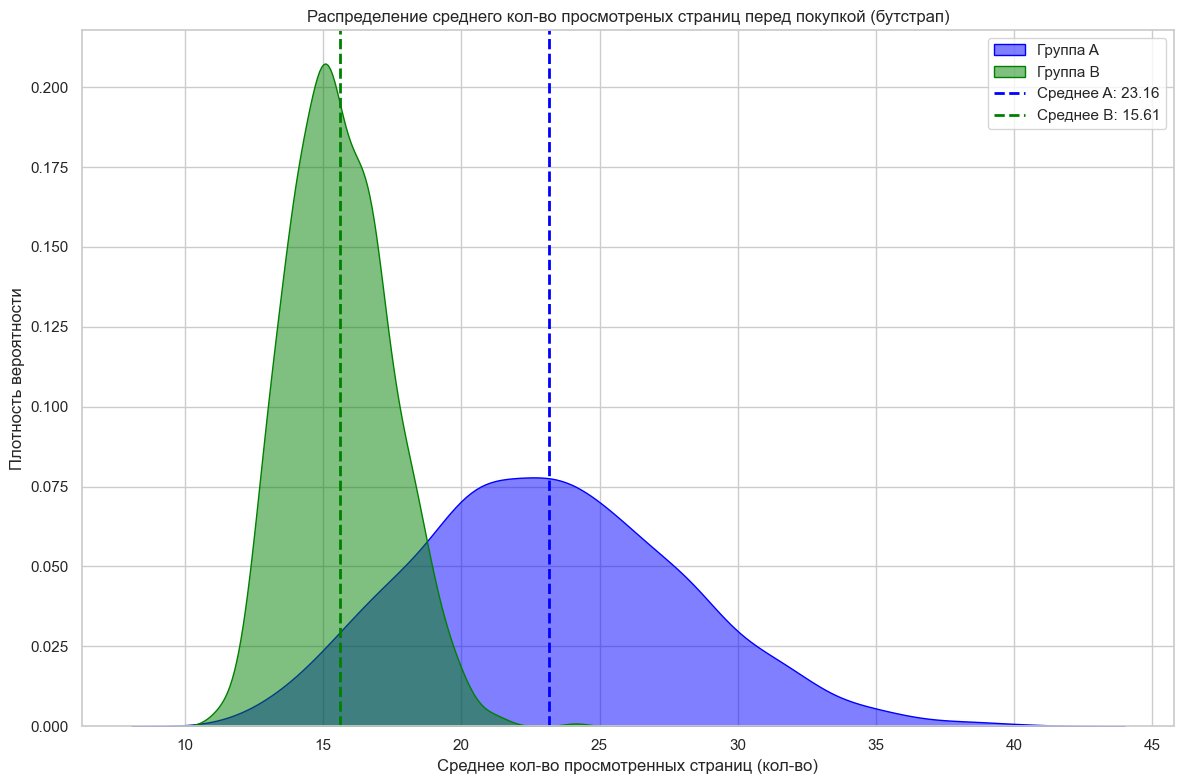

In [973]:
plt.figure(figsize=(12, 8))

sns.kdeplot(boot_a_time, label='Группа A',
            fill=True, color='blue', alpha=0.5)
sns.kdeplot(boot_b_time, label='Группа B',
            fill=True, color='green', alpha=0.5)
plt.axvline(np.mean(boot_a_time), color='blue', linestyle='dashed',
            linewidth=2, label=f'Среднее A: {np.mean(boot_a_time):.2f}')
plt.axvline(np.mean(boot_b_time), color='green', linestyle='dashed',
            linewidth=2, label=f'Среднее B: {np.mean(boot_b_time):.2f}')
plt.xlabel('Среднее кол-во просмотренных страниц (кол-во)')
plt.ylabel('Плотность вероятности')
plt.title('Распределение среднего кол-во просмотреных страниц перед покупкой (бутстрап)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Вывод по результатам A/B-теста:

Разница составляет `7.91` страниц в пользу группы `A`.

`p-value` = `0.177` превышает стандартный порог значимости (α = 0.05). Это означает, что разница между группами статистически незначима.

Бутстрап-распределения средних значений, вероятно, частично перекрываются, что подтверждает отсутствие значимости.

Несмотря на отсутствие статистической значимости, разница в `7.91` страниц может быть важна для бизнеса. Например, это может указывать на то, что изменения в группе `B` улучшили скорость покупки.



6. Вычислим `повторные визиты перед покупкой`.

Формула для нахождения повторных визитов перед покупкой:

`RR = кол-во пользователей, которые сделали покупку не в первый визит / всего покупателей`

In [974]:
# Преобразуем даты в формат datetime для удобства
visits['visit_date'] = pd.to_datetime(visits['visit_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Уберем время у order_date, так как в visit_date нет времени
orders['order_date'] = orders['order_date'].dt.normalize()

# Получаем пользователей, которые сделали покупку
purchasers = orders['user_id'].unique()

# Создаем DataFrame с визитами пользователей, которые сделали покупку
purchaser_visits = visits[visits['user_id'].isin(purchasers)]

# Группируем по 'group' и считаем количество визитов для каждого пользователя
visit_counts = purchaser_visits.groupby(['group', 'user_id']).size().reset_index(name='visit_count')

# Определяем, какие пользователи сделали покупку не в первый визит
repeat_visitors = visit_counts[visit_counts['visit_count'] > 1].groupby('group')['user_id'].nunique()

# Общее количество покупателей по группам
total_purchasers = purchaser_visits.groupby('group')['user_id'].nunique()

# Вычисляем коэффициент повторных визитов перед покупкой для каждой группы
RR = repeat_visitors / total_purchasers

print('Коэффициент повторных визитов перед покупкой по группам:')
print(RR)

Коэффициент повторных визитов перед покупкой по группам:
group
A    0.437500
B    0.413793
Name: user_id, dtype: float64


Нулевая гипотеза (`H0`): Коэффицент повторных визитов перед покупкой уменьшатся.

Альтернативная гипотеза (`H1`): Коэффицент повторных визитов перед покупкой увеличиться.

Для того чтобы подвердить или опровергнуть нулевую гипотезу найдем `p-value`.

In [975]:
repeat_visitors_visits = visit_counts[visit_counts['visit_count'] > 1]

# Разделяем данные на группы A и B
group_a = repeat_visitors_visits[repeat_visitors_visits['group'] == 'A']['visit_count']
group_b = repeat_visitors_visits[repeat_visitors_visits['group'] == 'B']['visit_count']

# Проводим t-test (предполагаем независимые выборки)
t_stat, p_value = ttest_ind(group_a, group_b)

print('\nP-value для коэффициента повторных визитов перед покупкой:', f'{p_value:.3f}')


P-value для коэффициента повторных визитов перед покупкой: 0.325


На основании полученного `p-value`, равного `0.325`, можно сделать следующий вывод:

`p-value` (`0.325`) > α: Это означает, что у нас недостаточно статистических доказательств, чтобы отвергнуть нулевую гипотезу.

Существует вероятность в `32.5%` получить наблюдаемую разницу в конверсии между группами `A` и `B`, если на самом деле нулевая гипотеза `верна`. 

Мы `не можем отвергнуть` нулевую гипотезу. Другими словами, у нас недостаточно данных, чтобы подтвердить, что изменения, статистически значимы и не являются случайными колебаниями.

In [976]:
fig = go.Figure()

fig.add_trace(go.Bar(x=RR.index,
                     y=RR.values,
                     marker_color=['yellow', 'green']))

fig.update_layout(height=500, width=1200,
                  title_text="Коэффициент повторных визитов перед покупкой", showlegend=False)
fig.update_yaxes(title_text="Визиты, кол-во")

fig.show()

Судя по графикам можно видеть, что разница в коэффецентах очень мала. Применим бутстрап метод.

In [977]:
def bootstrap_means(data, n_samples=1000):
    means = []
    for _ in range(n_samples):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return means

Создаем DataFrame с количеством визитов для каждого пользователя, совершившего покупку

Добавляем столбец с индикатором повторных визитов (visit_count > 1)

После чего разделяем данные на группы A и B

In [ ]:
visit_counts = purchaser_visits.groupby(['group', 'user_id']).size().reset_index(name='visit_count')

visit_counts['is_repeat'] = (visit_counts['visit_count'] > 1).astype(int)

 
groups = visit_counts['group'].unique()
group_a = visit_counts[visit_counts['group'] == groups[0]]['is_repeat']
group_b = visit_counts[visit_counts['group'] == groups[1]]['is_repeat']

Применяем бутстрап для оценки распределения RR

In [ ]:
boot_a = bootstrap_means(group_a)
boot_b = bootstrap_means(group_b)

Теперь построим график расспределения

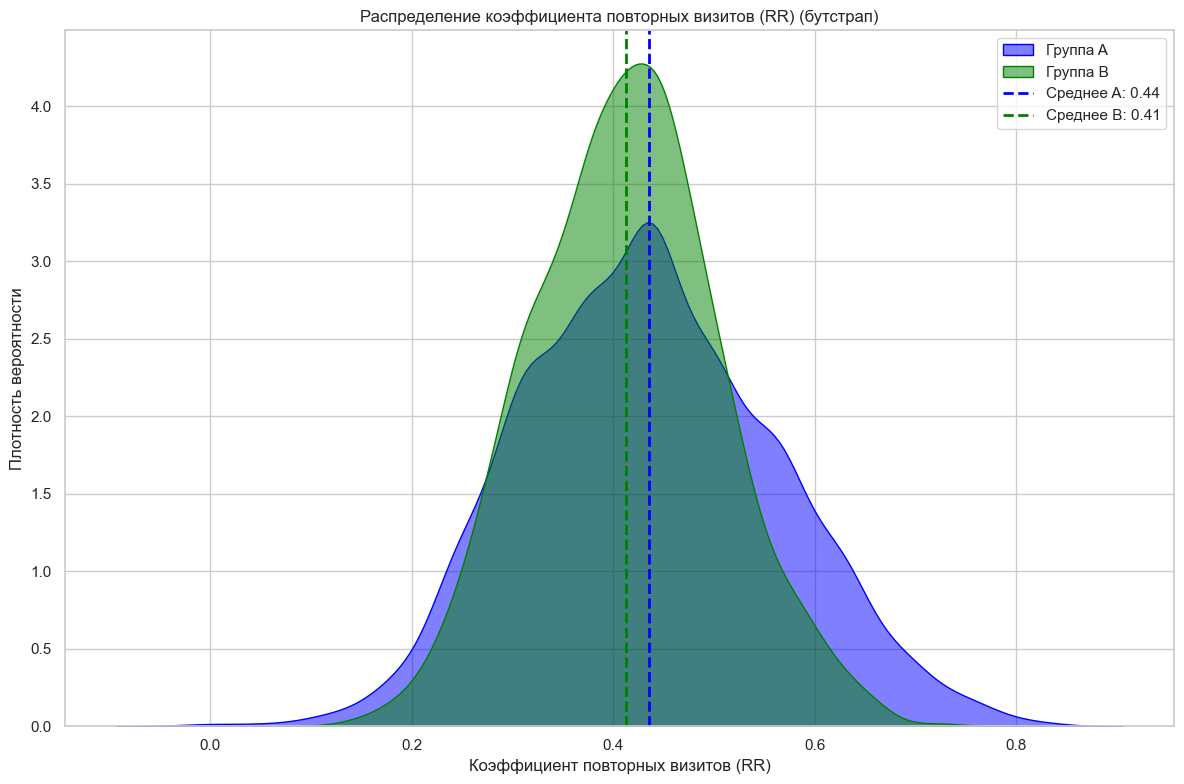

In [980]:
plt.figure(figsize=(12, 8))

sns.kdeplot(
    boot_a, label=f'Группа {groups[0]}', fill=True, color='blue', alpha=0.5)
sns.kdeplot(
    boot_b, label=f'Группа {groups[1]}', fill=True, color='green', alpha=0.5)

plt.axvline(np.mean(boot_a), color='blue', linestyle='dashed',
            linewidth=2, label=f'Среднее {groups[0]}: {np.mean(boot_a):.2f}')
plt.axvline(np.mean(boot_b), color='green', linestyle='dashed',
            linewidth=2, label=f'Среднее {groups[1]}: {np.mean(boot_b):.2f}')

plt.xlabel('Коэффициент повторных визитов (RR)')
plt.ylabel('Плотность вероятности')
plt.title('Распределение коэффициента повторных визитов (RR) (бутстрап)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

На основе графика группа `A` демонстрирует более высокий средний коэффициент повторных визитов (`RR = 0.44`) по сравнению с группой `B` (`RR = 0.41`). Разница между группами составляет 3 процентных пункта.

Бутстрап расспределение почти полностью перекрывается, что свидетельствует о статистической не значимости.

#### Вывод:

На основе проведенного анализа с использованием бутстрап-метода были получены следующие результаты по всем метрикам:

| Метрика                                          | Коэффициент группа А | Коэффициент группа B | p-value | Разница | Значимость    |
|--------------------------------------------------|----------------------|----------------------|---------|---------|---------------|
| Конверсия в покупку для Mobile                   | 7.69                 | 23.52                | 0.249   | +15.83  | Не значимо    |
| Конверсия в покупку для Desktop                  | 35.29                | 51.92                | 0.13    | +16.63  | Не значимо    |
| Средний чек                                      | 162.42               | 142.59               | 0.47    | -19.83  | Не значимо    |
| Срд. кол-во товаров в заказе                     | 2.00                 | 1.69                 | 0.284   | -0.31   | Не значимо    |
| Срд. время на сайте перед покупкой               | 746.05               | 206.67               | 0.005   | -539.38 | Значимо       |
| Срд. кол-во просмотренных страниц перед покупкой | 23.29                | 15.61                | 0.177   | -7.68   | Не значимо    |
| Срд. время на сайте перед покупкой               | 0.43                 | 0.41                 | 0.325   | -42.59  | Не значимо    |

Общие выводы и рекомендации:

Новый дизайн (группа B) демонстрирует:
   - Более быстрое время до покупки
   - Меньшее количество просмотренных страниц
   - Более низкий средний чек
   - Меньшее количество товаров в заказе
   - Низкий коэффициент повторных визитов

РЕКОМЕНДАЦИЯ: Можно смело обновлять сайт по следующим причинам:

- Более быстрое время до покупки
- Меньшее количество просмотренных страниц
- Низкий коэффициент повторных визитов

Эти причины демонстрируют, что новый дизайн сайта помогает проще и быстрее ориентироваться на сайте, что позволяет покупать товары быстрее (импульсивная покупка), но из-за этого теряем в среднем чеке и в кол-во, но это статистически не значемые показатели.

